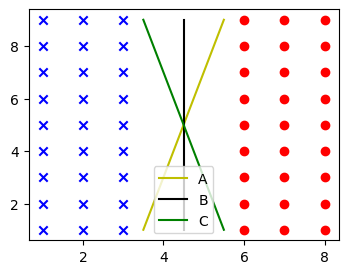

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4.0, 1:10].reshape(2, -1).T
right = np.mgrid[6:9.0, 1:10].reshape(2, -1).T

# data points
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')

# separating lines
ax.plot([3.5, 5.5], [1,9], 'y', label='A')
ax.plot([4.5, 4.5], [1,9], 'k', label='B')
ax.plot([3.5, 5.5], [9,1], 'g', label='C')
ax.legend(loc='lower center');

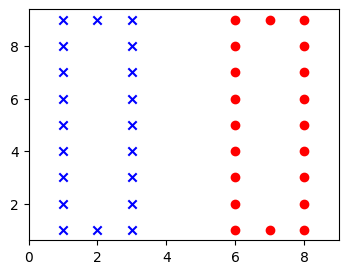

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4:2, 1:10].reshape(2, -1).T
right = np.mgrid[6:9:2, 1:10].reshape(2, -1).T

ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter([2,2], [1,9], c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.scatter([7,7], [1,9], c='r', marker='o')
ax.set_xlim(0,9);

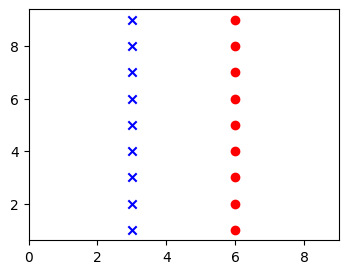

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

left  = np.mgrid[3:4, 1:10].reshape(2, -1).T
right = np.mgrid[6:7, 1:10].reshape(2, -1).T

ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.set_xlim(0,9);

In [ ]:
from sklearn import svm

sv_classifiers = {"SVC(Linear)"   : svm.SVC(kernel='linear'),
                  "NuSVC(Linear)" : svm.NuSVC(kernel='linear', nu=.9)}

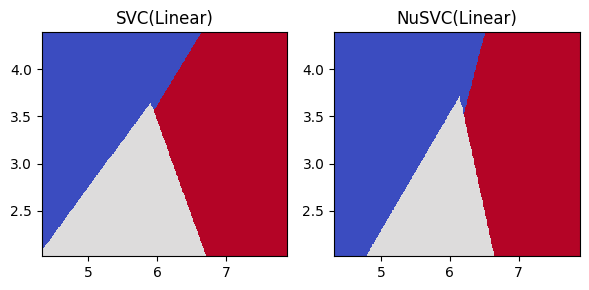

In [ ]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

from sklearn import datasets
iris = datasets.load_iris()

fig, axes = plt.subplots(1,2,figsize=(6,3))
for (name, mod), ax in zip(sv_classifiers.items(), axes.flat):
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()

In [ ]:
def do_linear_svc_separators(svc_maker, pname, params, ax):
    'create svc(params) and draw seperation boundary'
    xys = (np.linspace(2,8,100),
           np.linspace(2,8,100))

    for p in params:
        kwargs = {pname:p, 'kernel':'linear'}
        svc = svc_maker(**kwargs).fit(ftrs, tgt)
        # plot_separator is in mlwpy.py
        plot_separator(svc, *xys,
                       '{}={:g}'.format(pname, p), ax=ax)

#sa gist servera
def plot_separator(model, xs, ys, label='', ax=None):
    ''' xs, ys are 1-D b/c contour and decision_function
        use incompatible packaging '''
    if ax is None:
        ax = plt.gca()

    xy = np_cartesian_product(xs, ys)
    z_shape = (xs.size, ys.size) # verus shape[0]?
    zs = model.decision_function(xy).reshape(z_shape)

    contours = ax.contour(xs, ys, zs,
                          colors='k', levels=[0],
                          linestyles=['-'])
    fmt = {contours.levels[0] : label}
    labels = ax.clabel(contours, fmt=fmt, inline_spacing=10)
    [l.set_rotation(-90) for l in labels]

def np_cartesian_product(*arrays):
  ''' some numpy kung-fu to produce all
  possible combinations of input arrays '''
  ndim = len(arrays)
  return np.stack(np.meshgrid(*arrays), axis=-1).reshape(-1, ndim)


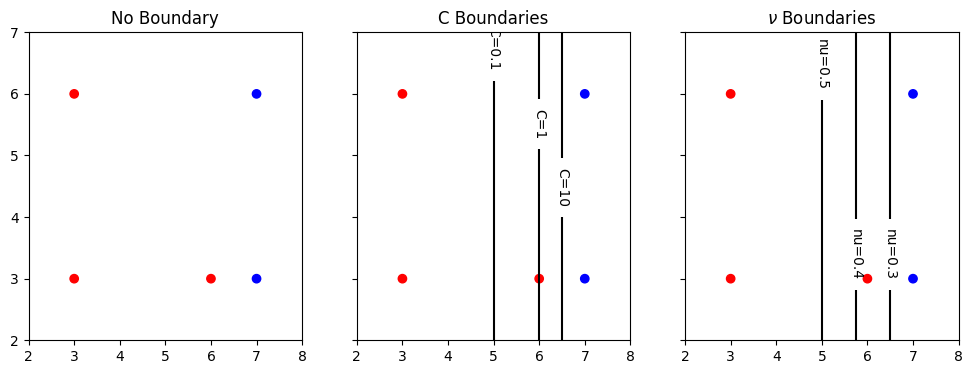

In [ ]:
ftrs = np.array([[3,3],
                 [3,6],
                 [7,3],
                 [7,6],
                 [6,3]])
tgt  = np.array([0,0,1,1,0])
colors = np.array(['r', 'b'])

Cs = [.1, 1.0, 10]
nus = [.3, .4, .5]

fig, axes = plt.subplots(1,3,figsize=(12,4),
                         sharex=True, sharey=True)
for ax in axes:
    ax.scatter(ftrs[:,0], ftrs[:,1], c=colors[tgt])
ax.set_xlim(2,8); ax.set_ylim(2,7)

do_linear_svc_separators(svm.SVC,   "C",   Cs, axes[1])
do_linear_svc_separators(svm.NuSVC, "nu", nus, axes[2])

axes[0].set_title("No Boundary")
axes[1].set_title("C Boundaries")
axes[2].set_title(r"$\nu$ Boundaries");

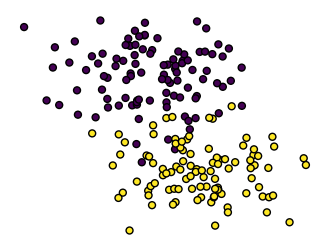

In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

ftrs, tgt = datasets.make_blobs(centers=2,
                                n_features=3,
                                n_samples=200,
                                center_box = (-2.0, 2.0),
                                random_state=20)

# note, using three features, but graphing only two dimensions
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(ftrs[:, 0], ftrs[:, 1],
           marker='o', c=tgt, s=25, edgecolor='k')
ax.axis('off');

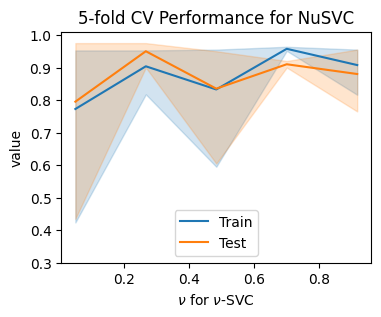

In [ ]:
import sklearn.model_selection as skms
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

nus = np.linspace(0.05, 2.0, 10)
tt = skms.validation_curve(svm.NuSVC(kernel='linear'),
                           ftrs, tgt,
                           param_name='nu',
                           param_range=nus,
                           cv=5)
train_scores, test_scores = tt
train_df = pd.DataFrame(train_scores).stack().reset_index()
train_df.columns = ['fold', 'nu_index', 'value']
train_df['nu'] = train_df['nu_index'].apply(lambda x: nus[x])
train_df = train_df.drop('nu_index', axis=1)
train_df['variable'] = 'Train'

test_df = pd.DataFrame(test_scores).stack().reset_index()
test_df.columns = ['fold', 'nu_index', 'value']
test_df['nu'] = test_df['nu_index'].apply(lambda x: nus[x])
test_df = test_df.drop('nu_index', axis=1)
test_df['variable'] = 'Test'

tt_df = pd.concat([train_df, test_df])

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax = sns.lineplot(data=tt_df,
                  x='nu',
                  y='value',
                  hue='variable')


ax.set_title('5-fold CV Performance for NuSVC')
ax.set_xlabel("\n".join([r'$\nu$ for $\nu$-SVC']))
ax.set_ylim(.3, 1.01)
ax.legend(loc='lower center');

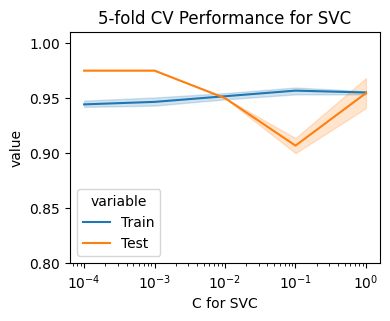

In [ ]:
import sklearn.model_selection as skms
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
cs = [0.0001, 0.001, 0.01, .1, 1.0, 10, 100, 1000]
tt = skms.validation_curve(svm.SVC(kernel='linear'),
ftrs, tgt,
param_name='C',
param_range=cs,
cv=5)
fig,ax = plt.subplots(1,1,figsize=(4,3))

train_scores, test_scores = tt

train_df = pd.DataFrame(train_scores).stack().reset_index()
train_df.columns = ['fold', 'C_index', 'value']
train_df['C'] = train_df['C_index'].apply(lambda x: cs[x])
train_df = train_df.drop('C_index', axis=1)
train_df['variable'] = 'Train'

test_df = pd.DataFrame(test_scores).stack().reset_index()
test_df.columns = ['fold', 'C_index', 'value']
test_df['C'] = test_df['C_index'].apply(lambda x: cs[x])
test_df = test_df.drop('C_index', axis=1)
test_df['variable'] = 'Test'

tt_df = pd.concat([train_df, test_df])

ax = sns.lineplot(data=tt_df,
                  x='C',
                  y='value',
                  hue='variable')

ax.set_title('5-fold CV Performance for SVC')
ax.set_xlabel("\n".join([r'C for SVC']))
ax.set_ylim(.8, 1.01)
ax.set_xscale('log')